In [1]:
import glob
import scipy
from scipy.interpolate import interp1d

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import os
import time
import pickle

import sklearn.metrics
import sklearn.decomposition

np.set_printoptions(suppress=True)

sample_templates = {0:'./templates/fluorescein_template.txt',
                   1:'./templates/tcqn_template.txt',
                   2:'./templates/ntcda_template.txt'}

or_files = glob.glob('*')

## Loading experimental files and matching measurement window

In [2]:
pure = ['F','T','N']
mixtures = ['FN','FT','TN','FTN1','FTN2', 'FTN3','FTN4', 'FTN5']

xrd_pure = {k: pd.read_csv(f"./experimental_measurements/{k}.uxd",header=None, skiprows=58, sep='\t').iloc[:,:2] for k in pure}
xrd_mix = {k: pd.read_csv(f"./experimental_measurements/{k}.uxd",header=None, skiprows=58, sep='\t').iloc[:,:2] for k in mixtures}

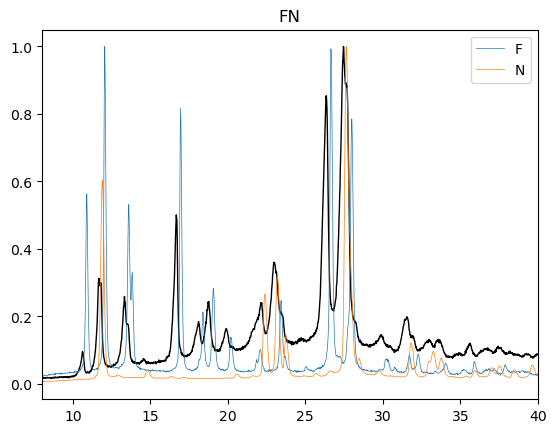

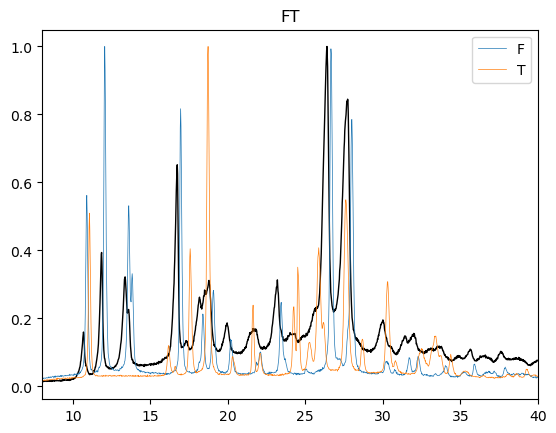

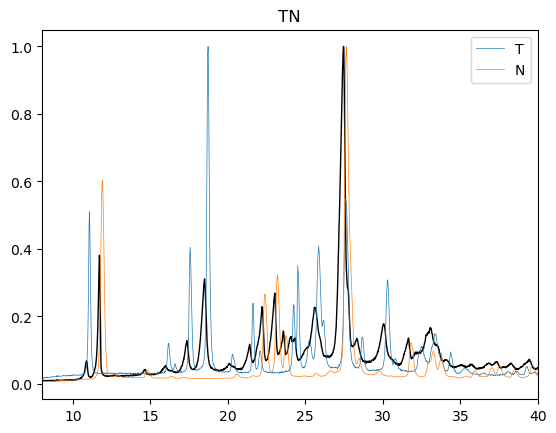

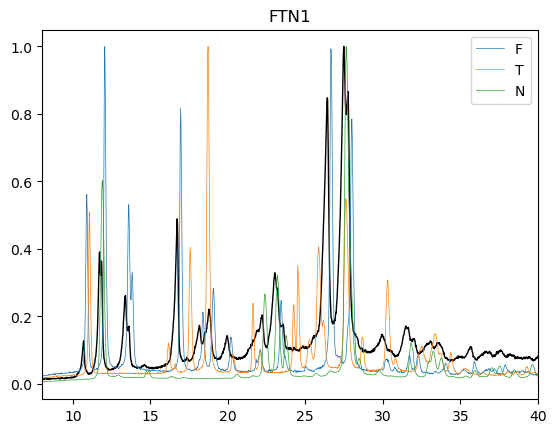

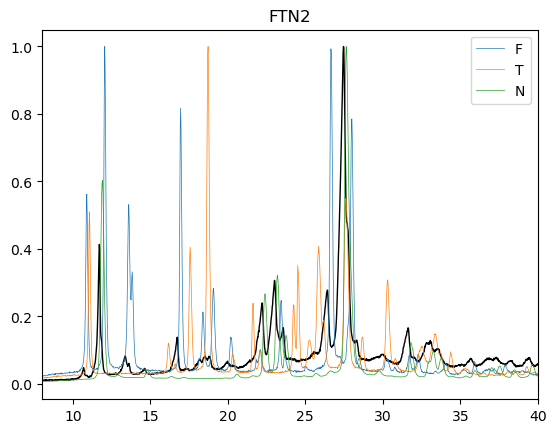

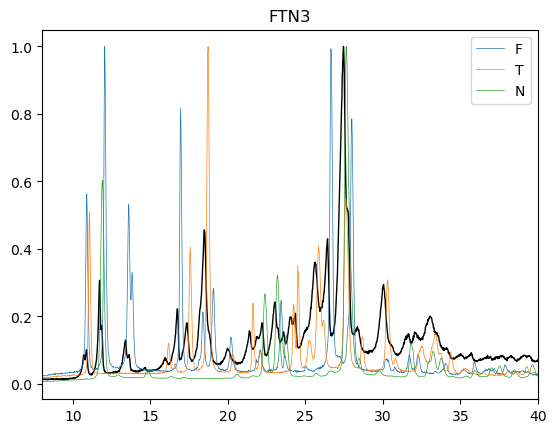

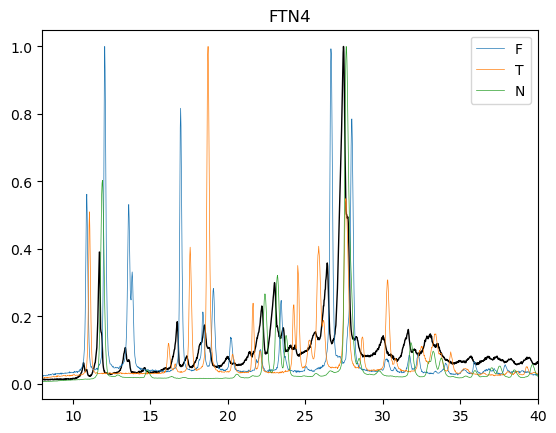

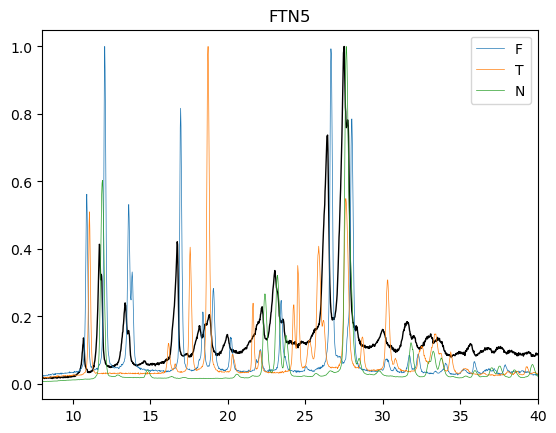

In [3]:
for k in xrd_mix.keys():
    
    plt.figure()
    plt.title(k)
    plt.plot(xrd_mix[k].iloc[:,0].values, xrd_mix[k].iloc[:,1]/np.max(xrd_mix[k].iloc[:,1]), linewidth=1, color='black')
    
    for kp in [i for i in k]:
        
        if kp in xrd_pure.keys():
            plt.plot(xrd_pure[kp].iloc[:,0].values, 
                     xrd_pure[kp].iloc[:,1]/np.max(xrd_pure[kp].iloc[:,1]), 
                     linewidth=0.5, label = kp)
        
    plt.legend(loc='best')
    plt.xlim(8,40)
    plt.show()


In [4]:
xmin = 15
xmax = 40

xsint = list()
for kp in xrd_pure.keys():
    
    dtheta = xrd_pure[kp].iloc[:,0].values
    xint = xrd_pure[kp].iloc[:,1].values
    
    xn = np.arange(xmin, xmax, (xmax-xmin)/2780)
    yn = scipy.interpolate.interp1d(dtheta, xint, kind='cubic')(xn)
    xsint += [yn]
xsint = np.stack(xsint)
xsint = np.expand_dims(xsint, axis=-1)

xmint = list()
for km in xrd_mix.keys():
    
    dtheta = xrd_mix[km].iloc[:,0].values
    xint = xrd_mix[km].iloc[:,1].values
    
    xn = np.arange(xmin, xmax, (xmax-xmin)/2780)
    yn = scipy.interpolate.interp1d(dtheta+0.4, xint, kind='cubic')(xn)
    xmint += [yn]
xmint = np.stack(xmint)
xmint = np.expand_dims(xmint, axis=-1)

xsint = (xsint - xsint.min(axis=(1,2), keepdims=True))/(xsint.max(axis=(1,2), keepdims=True) - xsint.min(axis=(1,2), keepdims=True))
xmint = (xmint - xmint.min(axis=(1,2), keepdims=True))/(xmint.max(axis=(1,2), keepdims=True) - xmint.min(axis=(1,2), keepdims=True))

xmint2 = np.asarray([[1,0,1],[1,1,0],[0,1,1],
                   [1,1,1],[1,1,1],[1,1,1],[1,1,1],[1,1,1]])

## Loading VAE

In [5]:
n_hidden = 139*5

vae = tf.keras.models.load_model('../VRB35.h5')
vae = tf.keras.Model(inputs=vae.inputs, outputs = vae.outputs, name='vae')
vae.trainable=False

encoder = tf.keras.Model(inputs=vae.inputs, outputs = vae.get_layer('z_vector').output, name='encoder')
decoder = tf.keras.Model(inputs = vae.get_layer('LC1_decoder').input, outputs = vae.get_layer('activation').output, name='decoder')

In [6]:
def gen_triple_phase(x, scaling=1):
    stepsize = 2

    samplings = list()

    interpolated = list()
    c_phase1 = list()
    c_phase2 = list()
    c_phase3 = list()
    ls = encoder(x, training=False)
    ls = ls.numpy()
    for n in np.arange(0,100 + stepsize, stepsize):
        sm = 100-n
        for s in np.arange(0,sm + stepsize, stepsize):
            samplings += [(n, s, sm-s)]
        
    samplings = 1e-2*np.asarray(samplings)
    interpolated = samplings @ ls

    interpolated = decoder.predict(interpolated)
    iphases = np.multiply(samplings[...,None], ls[None,...])
    
    x_phases = list()
    for n in range(3):
        x_phases += [decoder.predict(iphases[:,n,:], verbose=0)]
    x_phases = np.stack(x_phases)
    
    return np.concatenate((np.expand_dims(interpolated, axis=0), x_phases), axis=0), samplings


In [7]:
xrec, samplings = gen_triple_phase(x = xsint)
df = pd.DataFrame(samplings)

42/42 [==============================] - 2s 6ms/step


## Refinement

In [8]:
def append_placeholder(name = '', all_holders = list()):
    
    idx_diccio = {'fluorescein':0, 'tcqn':1, 'ntcda':2}
    placeholder = np.zeros((7,))
    f = open(f"{name}.out")
    
    for line in f.readlines():

        if 'r_wp' in line:
            placeholder[0] = float(line.split()[1])

        elif 'prm avrg_size_' in line or 'prm !avrg_size_' in line:
            _, om, size = line.split()[:3]
            placeholder[1+idx_diccio[om.split('_')[-1]]] = float(size.split('_')[0].split('`')[0])

        elif 'MVW' in line:
            placeholder[4+idx_diccio[om.split('_')[-1]]] = float(line.split(',')[-1].split('_')[0].split('`')[0])          

    all_holders += [placeholder]
    
    return all_holders

In [9]:
for n in range(xrec.shape[1]):
    pd.DataFrame({0:np.arange(15, 40, (40-15)/2780),
                 1:1e4*xrec[0,n,:,0]}).to_csv(f"triple_phase_{n}.xy", 
                                             header=None, index=None, sep='\t')

all_results = list()
for xy_file in glob.glob(f"triple_phase_*.xy"):

    idx = int(xy_file.split('_')[-1].split('.')[0])
    name = xy_file.split('.')[0]
    alphas = df.iloc[idx,:3].values
    tuples = [(i, alphas[i]) for i in reversed(np.argsort(alphas))]

    core_file = ''.join(open('templates/encabezado.txt','r')).replace('patron_de_difraccion', name)+'\n'
    count = 0
    
    all_holders = list()
    for n, phase in tuples:
        if phase != 0:
            if count == 0:
                core_file += ''.join(open(sample_templates[n],'r'))+'\n'
                core_file += "'**** TEMPLATE MARK ****\n"
                core_file += ''.join(open('templates/pie.txt','r')).replace('patron_de_difraccion', name) +'\n'

                with open(f"{name}.inp",'w') as f:
                    f.write(core_file)
                    f.close()
            else:
                core_file = ''.join(open(f"{name}.out",'r')).split("'**** TEMPLATE MARK ****")[0]
                core_file = core_file.replace('a @','a ').replace('b @','b ').replace('c @','c ').replace('be @','be ')
                core_file += ''.join(open(sample_templates[n],'r'))+'\n'
                core_file += "'**** TEMPLATE MARK ****\n"
                core_file += ''.join(open('templates/pie.txt','r')).replace('patron_de_difraccion', name) +'\n'

                with open(f"{name}.inp",'w') as f:
                    f.write(core_file)
                    f.close()
            count += 1    

            os.system(f"C:\\Topas-7\\tc.exe {name}.inp")            
            all_holders = append_placeholder(name=name, all_holders=all_holders)
            
            core_file = ''.join([i.split('latpars')[-1] if 'latpars' in i else i for i in open(f"{name}.out",'r').readlines()])
            with open(f"{name}.inp",'w') as f:
                f.write(core_file)
                f.close()
                
            os.system(f"C:\\Topas-7\\tc.exe {name}.inp")            
            all_holders = append_placeholder(name=name, all_holders=all_holders)
                       
    all_holders = np.stack(all_holders)   
    all_results += [all_holders[all_holders[:,0].argmin()]]
    if (idx+1)%100 == 0: print('Done for', idx+1)

        
df = df.rename(columns = {0:'alpha_F', 1:'alpha_T', 2: 'alpha_N'}).join(pd.DataFrame(all_results))
df = df.rename(columns={1:'sizeF',2:'sizeT', 3:'sizeN',
                       4:'concF', 5:'concT', 6:'concN', 0:'Rwp'})


Done for 100
Done for 200
Done for 300
Done for 400
Done for 500
Done for 600
Done for 700
Done for 800
Done for 900
Done for 1000
Done for 1100
Done for 1200
Done for 1300


In [10]:
idxmodel = df.index
dfmodel = df.iloc[idxmodel].reset_index(drop=True)

In [11]:
xmodel = (xrec[0] - xrec[0].min(axis=(1,2), keepdims=True))/(xrec[0].max(axis=(1,2), keepdims=True) - xrec[0].min(axis=(1,2), keepdims=True))
xmodel = xmodel[idxmodel]
ymodel = df[['concF','concT','concN']].values[idxmodel]/100

np.random.seed(10)
idxtest = np.random.choice(np.arange(xmodel.shape[0]),int(0.2*xmodel.shape[0]), replace=False)
idxtraval = np.setdiff1d(np.arange(xmodel.shape[0]), idxtest)

idxtraval = np.random.choice(idxtraval, len(idxtraval), replace=False)
idxtraval = np.random.choice(idxtraval, len(idxtraval), replace=False)
idxtraval = np.random.choice(idxtraval, len(idxtraval), replace=False)

ytraval = ymodel[idxtraval]
ytest = ymodel[idxtest]

xmodel2 = 1*(dfmodel.iloc[:,:3].values != 0)
xtraval2 = xmodel2[idxtraval]
xtest2 = xmodel2[idxtest]

xtraval = xmodel[idxtraval]
xtest = xmodel[idxtest]

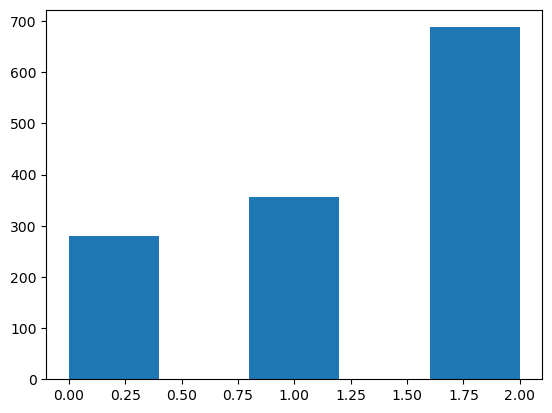

In [12]:
plt.figure()
plt.hist(ymodel.argmax(axis=-1), bins=5)
plt.show()

[0.7177 0.     0.2823]


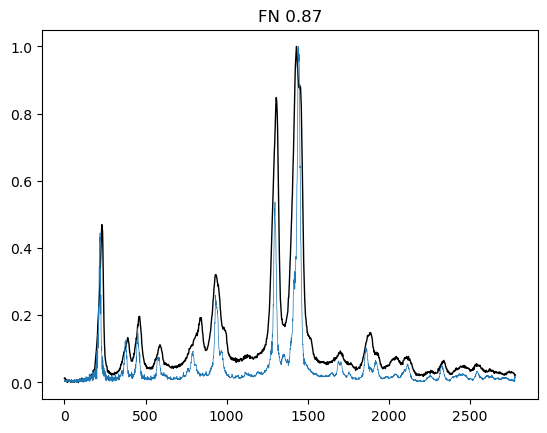

[0.7146 0.2854 0.    ]


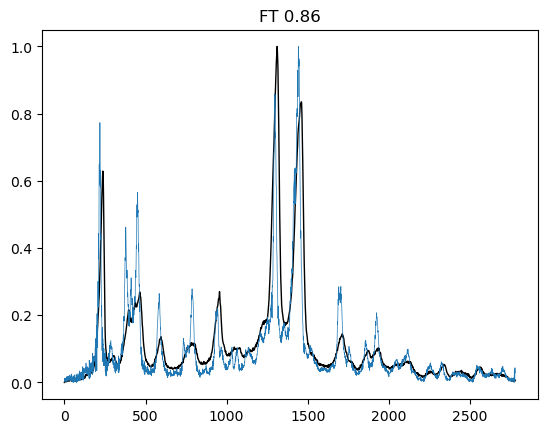

[0.      0.67825 0.32175]


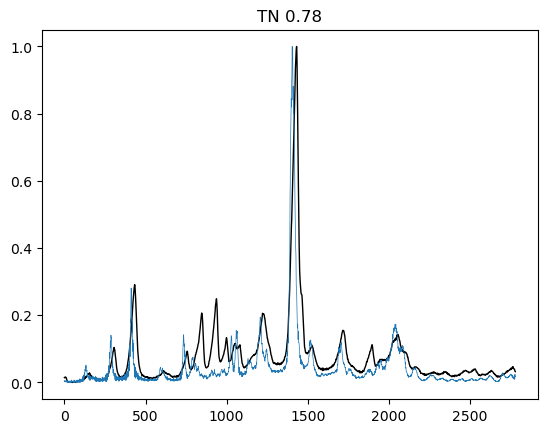

[0.52619 0.15526 0.31855]


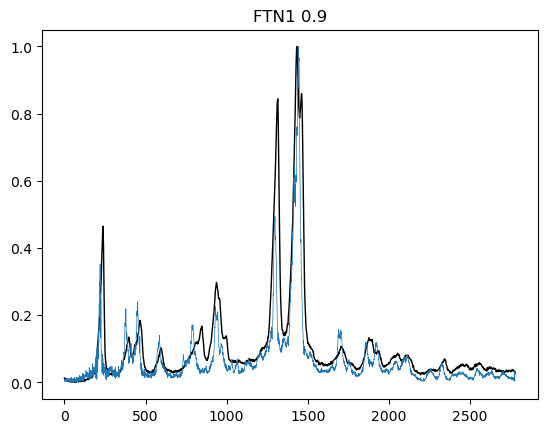

[0.25286 0.15117 0.59597]


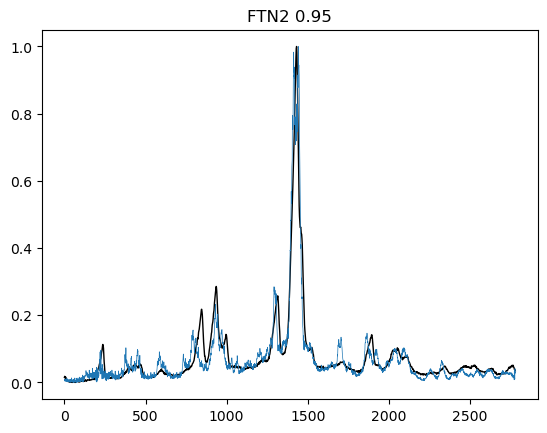

[0.29386 0.41444 0.2917 ]


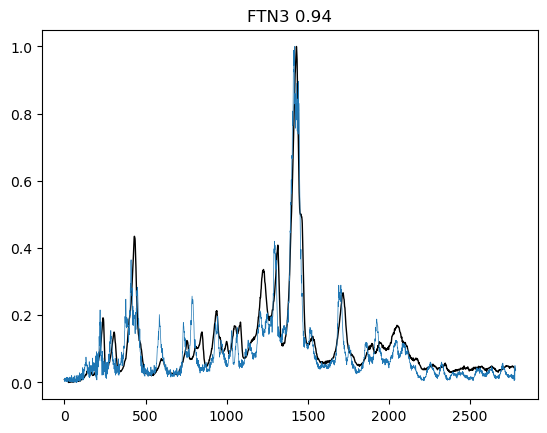

[0.30607 0.24742 0.44652]


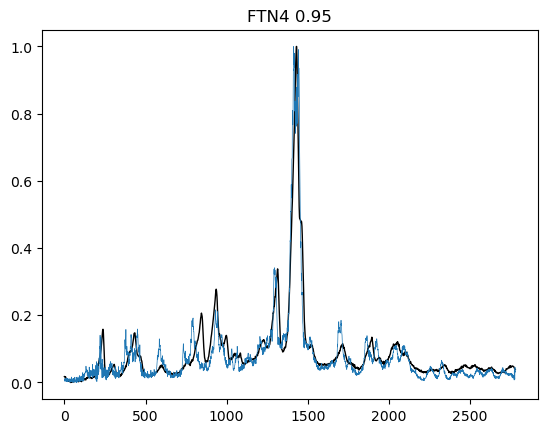

[0.48956 0.1804  0.33004]


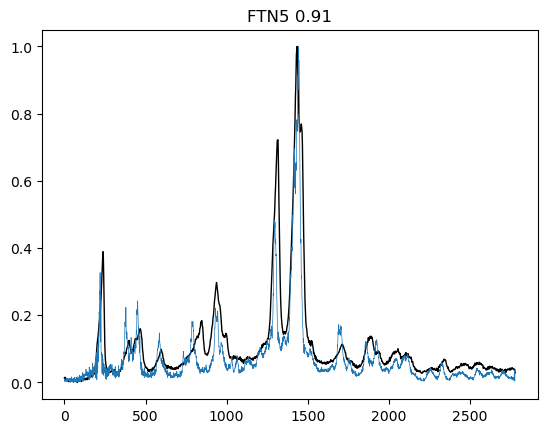

In [13]:
cossim = sklearn.metrics.pairwise.cosine_similarity(xmint[:,:,0], xmodel[:,:,0])
idx, ics = np.argmax(cossim, axis=1), np.max(cossim, axis=1)

for i in range(8):
    
    if i == 0: 
        corrected = cossim[i]*((df['concT'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)

    elif i == 1: 
        corrected = cossim[i]*((df['concN'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)        
    elif i == 2: 
        corrected = cossim[i]*((df['concF'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)
    else:
        iidx = idx[i]
        iics = ics[i]

    xmax = np.max(xmodel[iidx,:,0])
    plt.figure()
    print(ymodel[iidx])
    plt.title(f"{mixtures[i]} {np.round(iics,2)}")
    plt.plot(xmint[i,:,0], linewidth=1, color='black')
    plt.plot(xmodel[iidx,:,0]/xmax, linewidth=0.5)
    plt.show()

In [14]:
def cosine_similarity(xa, xb):
    
    xa = tf.linalg.normalize(xa, axis=-1)[0].numpy()
    xb = tf.linalg.normalize(xb, axis=-1)[0].numpy()
    
    return np.transpose(np.transpose(xa, (1,0,2)) @ np.transpose(xb, (1,2,0)), (1,2,0))

### Using features from pretrained model

In [15]:
modelo = tf.keras.models.load_model('../../pretrained_model.h5')
modelo.trainable = False

model_rb3 = tf.keras.models.Model(inputs = modelo.inputs[0], outputs = modelo.get_layer('activation_2').output, name='cropped_model_rb3')

xp = model_rb3.predict(xmodel)
xps = model_rb3.predict(xsint)
xpm = model_rb3.predict(xmint)

xptraval = xp[idxtraval]
xptest = xp[idxtest]

xanchor = np.reshape(np.transpose(cosine_similarity(xps, xp), (1,2,0)), (xp.shape[0],-1))
xeval = np.reshape(cosine_similarity(xpm, xps), (xpm.shape[0],-1))

1/1 [==============================] - 0s 41ms/step


[0.29919 0.      0.70081]


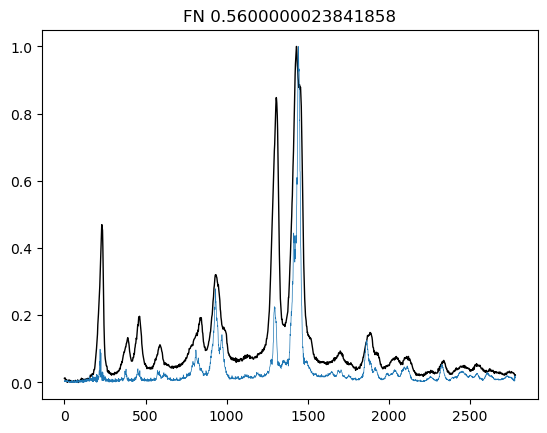

[0.67628 0.32372 0.     ]


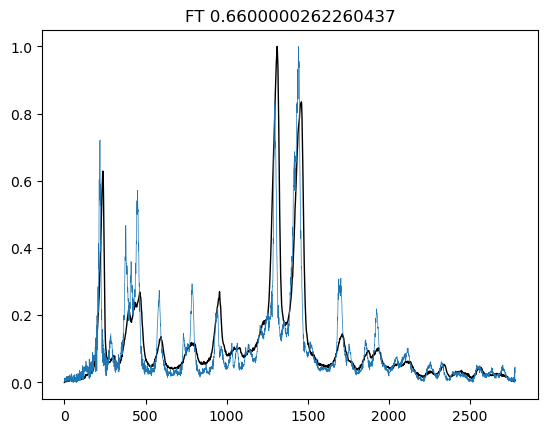

[0.      0.37744 0.62256]


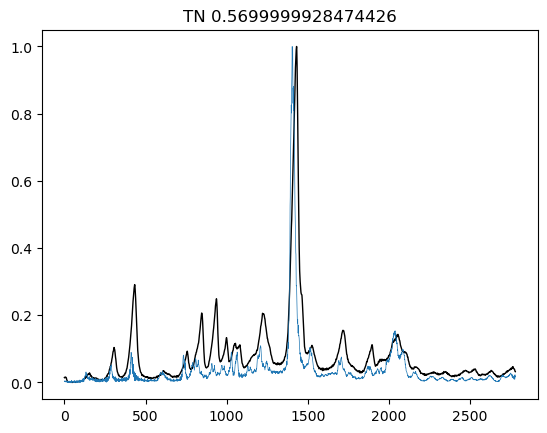

[0.33985 0.13334 0.52681]


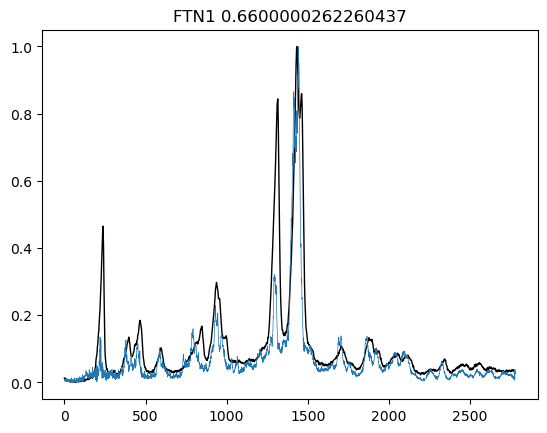

[0.17264 0.05921 0.76815]


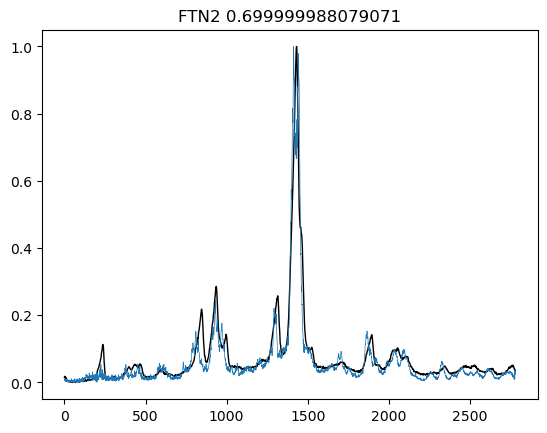

[0.18321 0.47678 0.34002]


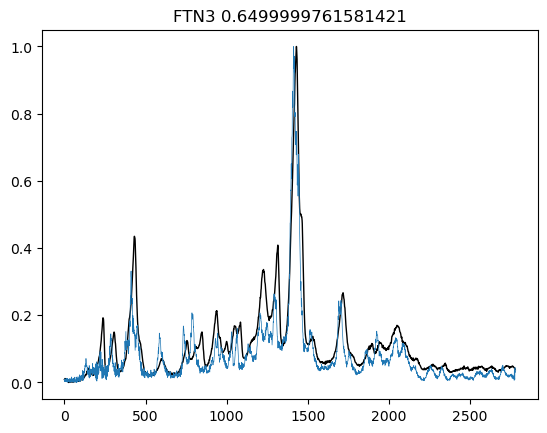

[0.2067  0.19011 0.60319]


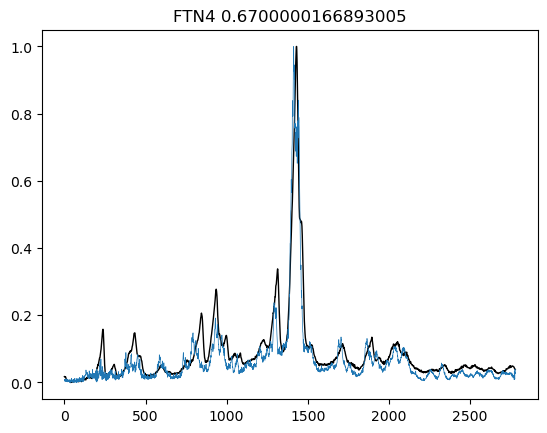

[0.29392 0.18893 0.51715]


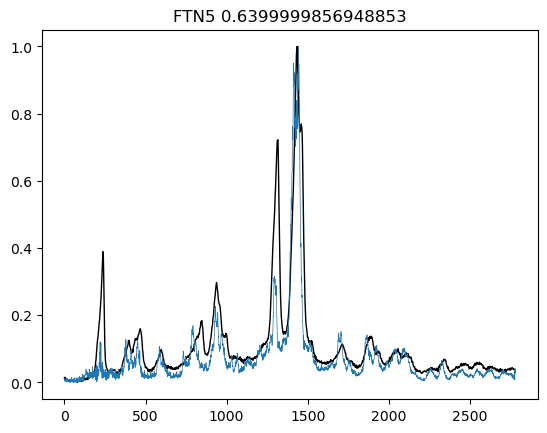

In [16]:
cossim = np.transpose(cosine_similarity(xp, xpm), (1,2,0)).mean(axis=1)
idx, ics = np.argmax(cossim, axis=1), np.max(cossim, axis=1)

for i in range(8):
    
    if i == 0: 
        corrected = cossim[i]*((df['concT'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)

    elif i == 1: 
        corrected = cossim[i]*((df['concN'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)        
    elif i == 2: 
        corrected = cossim[i]*((df['concF'].values == 0))
        iidx, iics = np.argmax(corrected), np.max(corrected)
    else:
        iidx = idx[i]
        iics = ics[i]

    xmax = np.max(xmodel[iidx,:,0])
    plt.figure()
    print(ymodel[iidx])
    plt.title(f"{mixtures[i]} {np.round(iics,2)}")
    plt.plot(xmint[i,:,0], linewidth=1, color='black')
    plt.plot(xmodel[iidx,:,0]/xmax, linewidth=0.5)
    plt.show()

### Definition of models

In [17]:
def pmregressor(name=''):
    input_layer = tf.keras.Input(shape=(139,96))

    x = tf.keras.layers.Dense(20)(input_layer)
    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.LeakyReLU(0)(x)
    x = tf.keras.layers.Dropout(0)(x)

    x = tf.keras.layers.Dense(x.shape[-1]*1)(x)
    x = tf.keras.layers.LeakyReLU(0)(x)
    x = tf.keras.layers.Dropout(0)(x)

    output = tf.keras.layers.Dense(3)(x)
    output = tf.keras.layers.Activation('softmax')(output)

    pann = tf.keras.Model(inputs=input_layer, outputs=output, name=f"pretrained_features_{name}")
    pann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss = tf.keras.losses.MeanAbsoluteError())
    
    return pann

def pmcondregressor(name=''):
    input_layer = tf.keras.Input(shape=(xanchor.shape[-1],))
    input_layer2 = tf.keras.Input(shape=(3,))

    x2 = tf.keras.layers.RepeatVector(139)(input_layer2)
    x2 = tf.keras.layers.Permute((2,1))(x2)
    x2 = tf.keras.layers.Flatten()(x2)

    xi = tf.keras.layers.Multiply()([input_layer, x2])
    xi = tf.keras.layers.Dense(420)(xi)
    xi = tf.keras.layers.Dropout(0.25)(xi)

    x = tf.keras.layers.Dense(xi.shape[-1]*2)(xi)
    x = tf.keras.layers.LeakyReLU(0.1)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Dense(xi.shape[-1])(x)
    x = tf.keras.layers.Add()([x, xi])
    x = tf.keras.layers.LeakyReLU(0.1)(x)

    output = tf.keras.layers.Dense(3)(x)
    output = tf.keras.layers.Activation('softmax')(output)

    ann = tf.keras.Model(inputs=[input_layer, input_layer2], outputs=output, name =f"pretrained_conditioned_{name}")
    ann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss = tf.keras.losses.MeanAbsoluteError())
    
    return ann

def lsregressor(name='', train_samples = 1, batch_size=1, epochs=1):
    input_layer = tf.keras.Input(shape=(2780,1))
    xi = encoder(input_layer, training=False)
    xi = tf.keras.layers.Dense(xi.shape[-1]*1)(xi)

    x = tf.keras.layers.Dense(xi.shape[-1]*2)(xi)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Dense(xi.shape[-1])(x)
    x = tf.keras.layers.Add()([x, xi])
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    output = tf.keras.layers.Dense(3)(x)
    output = tf.keras.layers.Activation('softmax')(output)

    ann = tf.keras.Model(inputs=input_layer, outputs=output, name=f"ls_{name}")

    INIT_LR = 1e-4        
    MIN_LR = 1e-6           
    lr = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=INIT_LR,
        first_decay_steps=(train_samples//batch_size)*epochs,  
        t_mul=1.0,               
        m_mul=1.0,               
        alpha=MIN_LR / INIT_LR   
    )

    ann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss = tf.keras.losses.MeanAbsoluteError())
    
    return ann

def lscond_regressor(name='', train_samples = 1, batch_size=1, epochs=1):
    input_layer = tf.keras.Input(shape=(2780,1))
    input_layer2 = tf.keras.Input(shape=(3,))

    xi = encoder(input_layer, training=False)
    xi = tf.keras.layers.Concatenate()([xi, input_layer2])
    xi = tf.keras.layers.Dense(700)(xi)

    x = tf.keras.layers.Dense(xi.shape[-1]*2)(xi)
    x = tf.keras.layers.LeakyReLU(0.15)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    x = tf.keras.layers.Dense(xi.shape[-1])(x)
    x = tf.keras.layers.Add()([x, xi])
    x = tf.keras.layers.LeakyReLU(0.15)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    output = tf.keras.layers.Dense(3)(x)
    output1 = tf.keras.layers.Multiply()([output, input_layer2])

    mask = tf.keras.layers.Lambda(lambda x:1e8*(1-x))(input_layer2)
    output2 = tf.keras.layers.Multiply()([mask, output])
    output = tf.keras.layers.Add()([output1, output2])
    output = tf.keras.layers.Activation('softmax')(output)

    ann = tf.keras.Model(inputs=[input_layer, input_layer2], outputs=output, name=f"conditioned_ls_features_{name}")

    INIT_LR = 1e-4        
    MIN_LR = 1e-6           
    lr = tf.keras.optimizers.schedules.CosineDecayRestarts(
        initial_learning_rate=INIT_LR,
        first_decay_steps=(train_samples//batch_size)*epochs,  
        t_mul=1.0,               
        m_mul=1.0,               
        alpha=MIN_LR / INIT_LR   
    )

    ann.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss = tf.keras.losses.MeanAbsoluteError())

    return ann


### First experiments (not definitive)

In [18]:
models = dict()
predictions = dict()
num_models = 10
for item in range(num_models):
    print('Set', item+1,'/',num_models)
    models[item+1] = dict()
    predictions[item+1] = dict()
    
    pann = pmregressor(name=item+1)
    pann.fit(xptraval, ytraval, batch_size=128, epochs=80, validation_data=(xptest, ytest), verbose=0)
    ptest_p = pann.predict(xptest)
    pann.trainable=False
    print('Pretrained features', sklearn.metrics.r2_score(ytest, ptest_p))
    prediction = np.round(pann.predict(xpm),4)
    print(prediction,'\n')
    
    predictions[item+1]['pmodel'] = prediction
    models[item+1]['pmodel'] = pann
    
    pcann = pmcondregressor(name=item+1)
    pcann.fit([xanchor[idxtraval], xtraval2], ytraval, batch_size=128, 
             epochs=80, validation_data=([xanchor[idxtest], xtest2], ytest), verbose=0)
    ptest_pc = pcann.predict([xanchor[idxtest], xtest2])
    pcann.trainable=False
    print('Pretrained conditioned features', sklearn.metrics.r2_score(ytest, ptest_pc))
    prediction = np.round(pcann.predict([xeval, xmint2]),4)
    print(prediction,'\n')
    
    predictions[item+1]['pcmodel'] = prediction
    models[item+1]['pcmodel'] = pcann
    
    lsann = lsregressor(name=item+1, train_samples=xtraval.shape[0], batch_size=32, epochs=250)
    lsann.fit(xtraval, ytraval, batch_size=32, epochs=250, validation_data = (xtest, ytest), verbose=0)
    ptest_ls = lsann.predict(xtest)
    lsann.trainable=False
    print('LS features', sklearn.metrics.r2_score(ytest, ptest_ls))
    prediction = np.round(lsann.predict(xmint),4)
    print(prediction,'\n')
    
    predictions[item+1]['lsmodel'] = prediction
    models[item+1]['lsmodel'] = lsann
    
    lscann = lscond_regressor(name=item+1, train_samples=xtraval.shape[0], batch_size=32, epochs=250)
    lscann.fit([xtraval, xtraval2], ytraval, batch_size=32, epochs=250, 
               validation_data = ([xtest, xtest2], ytest), verbose=0)
    ptest_lscond = lscann.predict([xtest, xtest2])
    lscann.trainable=False
    print('LS conditioned features', sklearn.metrics.r2_score(ytest, ptest_lscond))
    prediction = np.round(lscann.predict([xmint, xmint2]),4)
    print(prediction,'\n')
    
    predictions[item+1]['lscmodel'] = prediction
    models[item+1]['lscmodel'] = lscann    

Set 1 / 10
9/9 [==============================] - 0s 2ms/step
Pretrained features 0.9986265323168267
1/1 [==============================] - 0s 39ms/step
[[0.5273 0.1497 0.323 ]
 [0.6156 0.1871 0.1973]
 [0.0518 0.4118 0.5364]
 [0.4542 0.2123 0.3335]
 [0.2533 0.1367 0.61  ]
 [0.2215 0.5008 0.2777]
 [0.2467 0.2609 0.4924]
 [0.473  0.2925 0.2345]] 

9/9 [==============================] - 0s 3ms/step
Pretrained conditioned features 0.9965809059557676
1/1 [==============================] - 0s 6ms/step
[[0.3757 0.0573 0.567 ]
 [0.6186 0.3195 0.0619]
 [0.0613 0.3194 0.6193]
 [0.356  0.1397 0.5043]
 [0.2508 0.0914 0.6578]
 [0.2831 0.2465 0.4703]
 [0.2963 0.1399 0.5639]
 [0.3614 0.1607 0.4779]] 

9/9 [==============================] - 0s 3ms/step
LS features 0.9975174499129857
1/1 [==============================] - 0s 21ms/step
[[0.4053 0.1153 0.4794]
 [0.4553 0.2703 0.2745]
 [0.1101 0.2562 0.6337]
 [0.4106 0.1179 0.4715]
 [0.2112 0.083  0.7057]
 [0.2128 0.3102 0.4771]
 [0.2293 0.1766 0.5941]
 [

9/9 [==============================] - 0s 3ms/step
Pretrained features 0.9965644001625161
1/1 [==============================] - 0s 16ms/step
[[0.5763 0.1288 0.2949]
 [0.6544 0.2163 0.1293]
 [0.0706 0.3611 0.5683]
 [0.5525 0.2083 0.2392]
 [0.2872 0.1253 0.5875]
 [0.2494 0.5228 0.2278]
 [0.2941 0.2766 0.4293]
 [0.604  0.1973 0.1986]] 

9/9 [==============================] - 0s 2ms/step
Pretrained conditioned features 0.9945081621228905
1/1 [==============================] - 0s 22ms/step
[[0.3346 0.0439 0.6215]
 [0.7839 0.1801 0.036 ]
 [0.0608 0.2691 0.6702]
 [0.3832 0.1091 0.5077]
 [0.3117 0.1123 0.576 ]
 [0.3011 0.2904 0.4085]
 [0.3303 0.1669 0.5028]
 [0.4245 0.1245 0.451 ]] 

9/9 [==============================] - 0s 3ms/step
LS features 0.9965654328342018
1/1 [==============================] - 0s 11ms/step
[[0.3913 0.1057 0.503 ]
 [0.4311 0.2523 0.3166]
 [0.0868 0.2704 0.6428]
 [0.3827 0.1322 0.4851]
 [0.192  0.079  0.7289]
 [0.1681 0.3555 0.4764]
 [0.2148 0.1545 0.6307]
 [0.3401 0.1

1031 [0.37895 0.04936 0.57169]


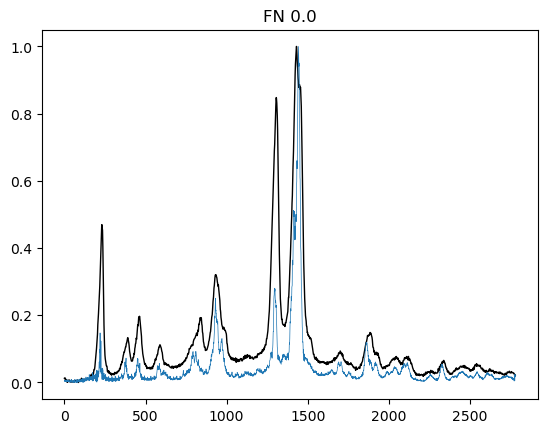

1153 [0.62151 0.2515  0.12699]


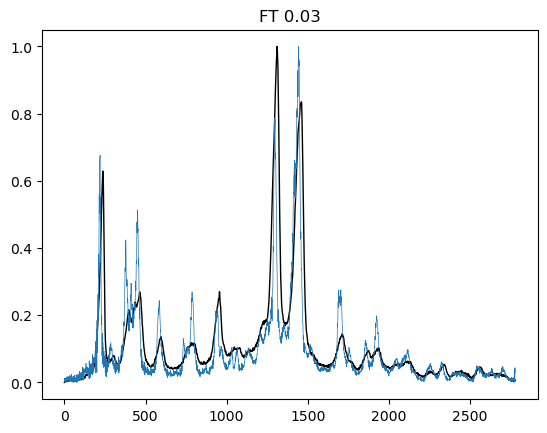

403 [0.05503 0.29237 0.6526 ]


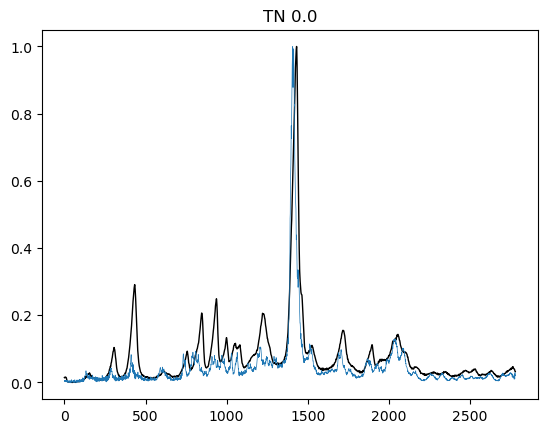

933 [0.33985 0.13334 0.52681]


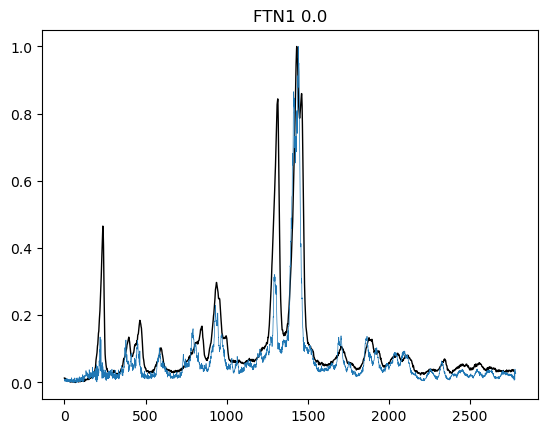

873 [0.25304 0.10046 0.6465 ]


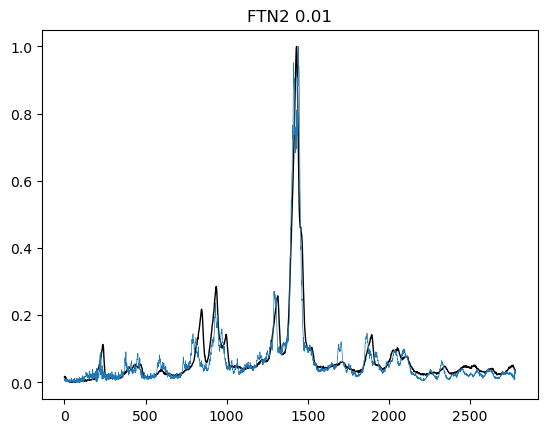

879 [0.24322 0.2897  0.46708]


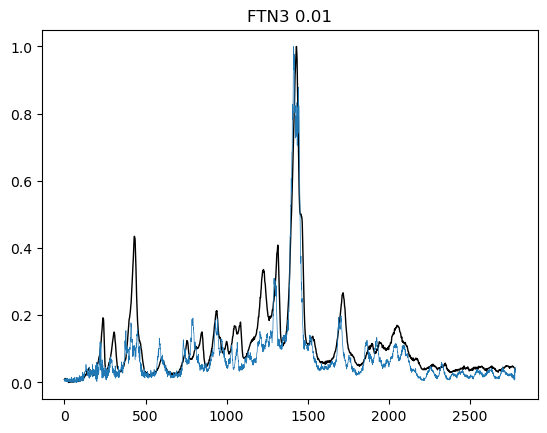

875 [0.26007 0.18024 0.55969]


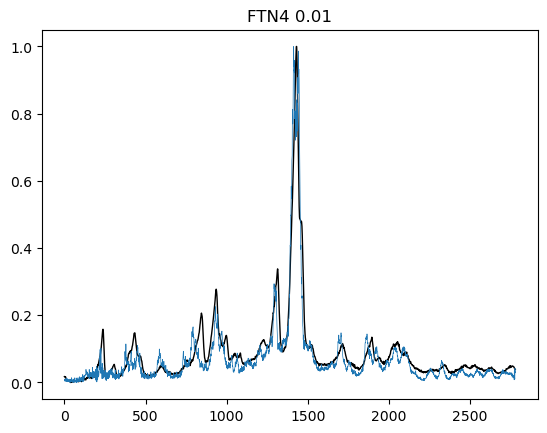

933 [0.33985 0.13334 0.52681]


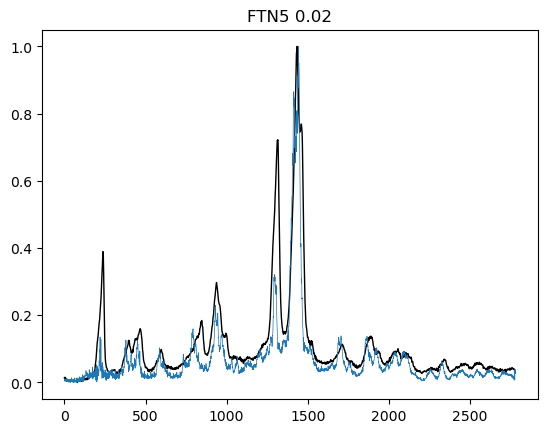

In [19]:
ypred = np.stack([predictions[i+1]['pcmodel'] for i in range(10)]).mean(axis=0)
mae = np.mean(np.abs(np.transpose(ymodel)[...,None] - np.transpose(ypred)[:,None,:]), axis=0).T 
idx, ics = np.argmin(mae, axis=1), np.min(mae, axis=1)

for i in range(8):
    xmax = np.max(xmint[i,:,0])
    print(idx[i], ymodel[idx[i]])
    plt.figure()
    plt.title(f"{mixtures[i]} {np.round(ics[i],2)}")
    plt.plot(xmint[i,:,0]/xmax, linewidth=1, color='black')
    plt.plot(xmodel[idx[i],:,0], linewidth=0.5)
    
    plt.show()

In [20]:
directorio = time.ctime().replace(' ', ':').split(':')[1:]
directorio.pop(-2)
directorio = '_'.join(directorio)
os.system('mkdir ' + directorio)

0

In [21]:
idx_diccio = dict()
idx_diccio['model'] = idxmodel
idx_diccio['traval'] = idxtraval
idx_diccio['test'] = idxtest

with open(f"{directorio}/idx_diccio.pkl",'wb') as f:
    pickle.dump(idx_diccio, f)

df.to_csv(f"{directorio}/estimated_concentrations.csv", index=None)
np.save(f"{directorio}/generated_xrds.npy", xrec)
    
with open(f"{directorio}/predictions.pkl",'wb') as f:
    pickle.dump(predictions, f)
    
for key in models.keys():
    for subkey in models[key]:
        models[key][subkey].save(f"{directorio}/{subkey}_{key}.h5")

In [22]:
!del *.xy *.inp *.out